# Quick EDA: combined_diseases_symptoms_2_enriched_with_exams_v2.csv

This notebook performs a quick exploratory data analysis on the `combined_diseases_symptoms_2_enriched_with_exams_v2.csv` artifact.
It loads the CSV, parses JSON-encoded columns (`candidate_diseases`, `recommended_exams_tests`), computes summary statistics, and produces several plots and CSV summaries suitable for quick inspection and for use in Kaggle documentation.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
from pathlib import Path
from collections import Counter
sns.set(style='whitegrid')
%matplotlib inline

In [2]:
# Path to the CSV (adjust if necessary)
csv_path = Path('combined_diseases_symptoms_2_enriched_with_exams_v2.csv')
if not csv_path.exists():
    print(f'File not found: {csv_path}. Upload the CSV or adjust the path to where the file is located in the runtime environment.')
else:
    # Read as strings to avoid dtype surprises
    df = pd.read_csv(csv_path, dtype=str)
    print('Loaded dataset with', len(df), 'rows and', len(df.columns), 'columns')

Loaded dataset with 248126 rows and 7 columns


In [3]:
# Basic inspection
if 'df' in globals():
    display(df.head())
    print('Shape:', df.shape)
    print('Columns and dtypes:')
    display(df.dtypes)

,input,output,source,support_status,candidate_diseases,recommended_exams_tests,reasoning
0,"anxiety and nervousness, shortness of breath, ...",panic disorder,ds1_diseases_symptoms,supported,"[""panic disorder""]","[""complete blood count (CBC)"", ""electrocardiog...",<think>The symptom constellation includes depr...
1,"shortness of breath, depressive or psychotic s...",panic disorder,ds1_diseases_symptoms,inconclusive,"[""generalised anxiety disorder"", ""panic attack...","[""complete blood count (CBC)"", ""electrocardiog...",<think>The symptom constellation includes depr...
2,"anxiety and nervousness, depression, shortness...",panic disorder,ds1_diseases_symptoms,supported,"[""panic disorder""]","[""complete blood count (CBC)"", ""electrocardiog...",<think>The symptom constellation includes depr...
3,"anxiety and nervousness, depressive or psychot...",panic disorder,ds1_diseases_symptoms,inconclusive,"[""generalised anxiety disorder"", ""panic attack...","[""complete blood count (CBC)"", ""electrocardiog...",<think>The symptom constellation includes depr...
4,"anxiety and nervousness, depression, insomnia,...",panic disorder,ds1_diseases_symptoms,inconclusive,"[""generalised anxiety disorder"", ""panic attack...","[""complete blood count (CBC)"", ""electrocardiog...",<think>The symptom constellation includes inso...


Shape: (248126, 7)
Columns and dtypes:


input                      str
output                     str
source                     str
support_status             str
candidate_diseases         str
recommended_exams_tests    str
reasoning                  str
dtype: object

In [4]:
# Missing values summary (counts and empty strings)
if 'df' in globals():
    na_counts = df.isna().sum()
    empty_counts = (df == '').sum()
    missing_df = pd.DataFrame({'missing_na': na_counts, 'empty_str': empty_counts})
    missing_df['total_missing'] = missing_df['missing_na'] + missing_df['empty_str']
    display(missing_df)

,missing_na,empty_str,total_missing
input,0,0,0
output,0,0,0
source,0,0,0
support_status,0,0,0
candidate_diseases,0,0,0
recommended_exams_tests,0,0,0
reasoning,0,0,0


support_status value counts:


support_status
inconclusive    192260
supported        55866
Name: count, dtype: int64

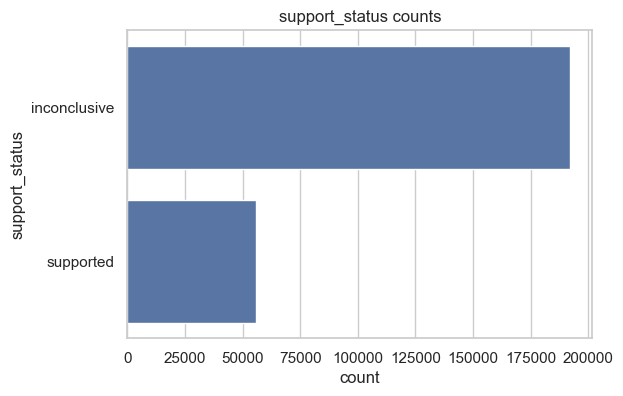

In [5]:
# support_status distribution and plot
if 'df' in globals():
    if 'support_status' in df.columns:
        ss = df['support_status'].fillna('')
        print('support_status value counts:')
        display(ss.value_counts(dropna=False))
        plt.figure(figsize=(6,4))
        sns.countplot(y=ss, order=ss.value_counts().index)
        plt.title('support_status counts')
        plt.xlabel('count')
        plt.ylabel('support_status')
        plt.show()
    else:
        print('Column "support_status" not present in the dataset.')

In [6]:
# Helper to safely parse JSON-encoded lists (or Python literal lists)
def parse_json_list(s):
    if s is None:
        return []
    if isinstance(s, list):
        return s
    s = str(s).strip()
    if s == '' or s.lower() == 'nan':
        return []
    try:
        val = json.loads(s)
        if isinstance(val, list):
            return val
        else:
            return [val]
    except Exception:
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return val
            else:
                return [val]
        except Exception:
            # fallback: split on comma
            return [item.strip() for item in s.split(',') if item.strip()]

# Parse candidate and exams columns into list columns
if 'df' in globals():
    for col in ['candidate_diseases', 'recommended_exams_tests']:
        parsed_col = col + '_parsed'
        if col in df.columns:
            df[parsed_col] = df[col].apply(parse_json_list)
        else:
            df[parsed_col] = [[] for _ in range(len(df))]
    # counts
    df['num_candidate_diseases'] = df['candidate_diseases_parsed'].apply(len)
    df['num_recommended_exams'] = df['recommended_exams_tests_parsed'].apply(len)
    display(df[['candidate_diseases', 'candidate_diseases_parsed', 'num_candidate_diseases']].head())

,candidate_diseases,candidate_diseases_parsed,num_candidate_diseases
0,"[""panic disorder""]",[panic disorder],1
1,"[""generalised anxiety disorder"", ""panic attack...","[generalised anxiety disorder, panic attack, c...",3
2,"[""panic disorder""]",[panic disorder],1
3,"[""generalised anxiety disorder"", ""panic attack...","[generalised anxiety disorder, panic attack, c...",3
4,"[""generalised anxiety disorder"", ""panic attack...","[generalised anxiety disorder, panic attack, c...",3


Top candidate diseases (top 20):


,disease,count
0,acute pancreatitis,42202
1,cholecystitis,34309
2,infectious gastroenteritis,33409
3,cardiac arrhythmia,30306
4,panic attack,26891
5,generalised anxiety disorder,26788
6,pneumonia,23241
7,acute bronchitis,22916
8,eczema,20477
9,psoriasis,19624


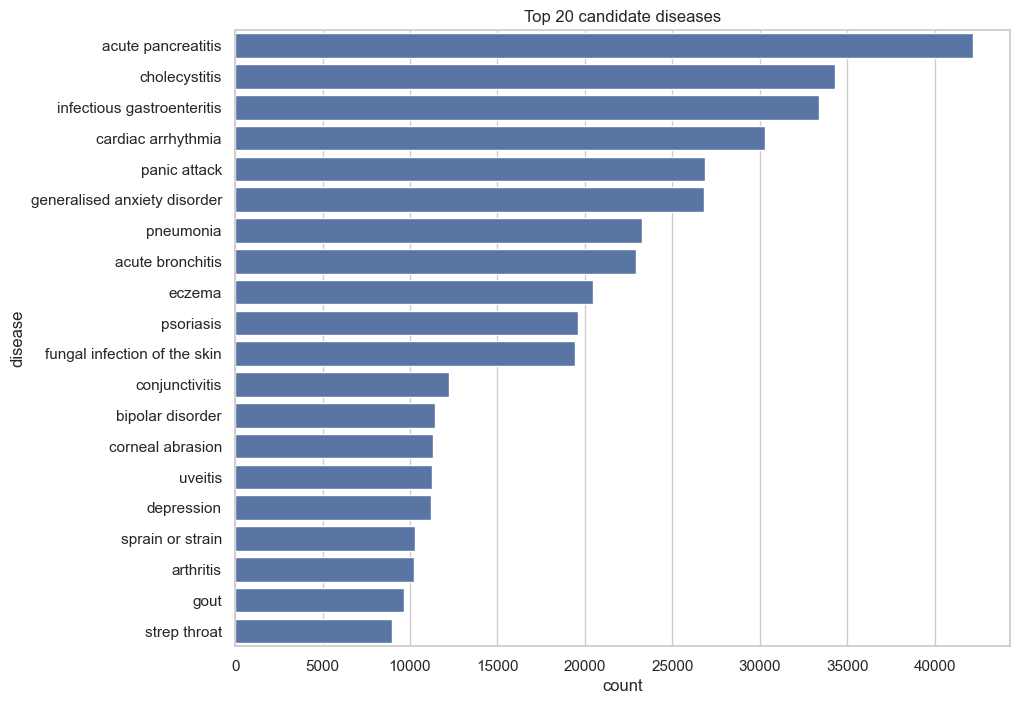

In [7]:
# Top candidate diseases (aggregate across rows)
if 'df' in globals():
    c = Counter()
    df['candidate_diseases_parsed'].apply(c.update)
    top_candidates = c.most_common(30)
    top_df = pd.DataFrame(top_candidates, columns=['disease','count'])
    print('Top candidate diseases (top 20):')
    display(top_df.head(20))
    plt.figure(figsize=(10,8))
    sns.barplot(x='count', y='disease', data=top_df.head(20))
    plt.title('Top 20 candidate diseases')
    plt.xlabel('count')
    plt.ylabel('disease')
    plt.show()

Top recommended exams/tests (top 20):


,exam,count
0,complete blood count (CBC),240559
1,X-ray,71202
2,comprehensive metabolic panel (CMP),65153
3,abdominal ultrasound,50815
4,pulse oximetry,46036
5,electrocardiogram (ECG),45933
6,chest X-ray,37456
7,serum lipase,32101
8,dermatologic examination,30434
9,urinalysis,28249


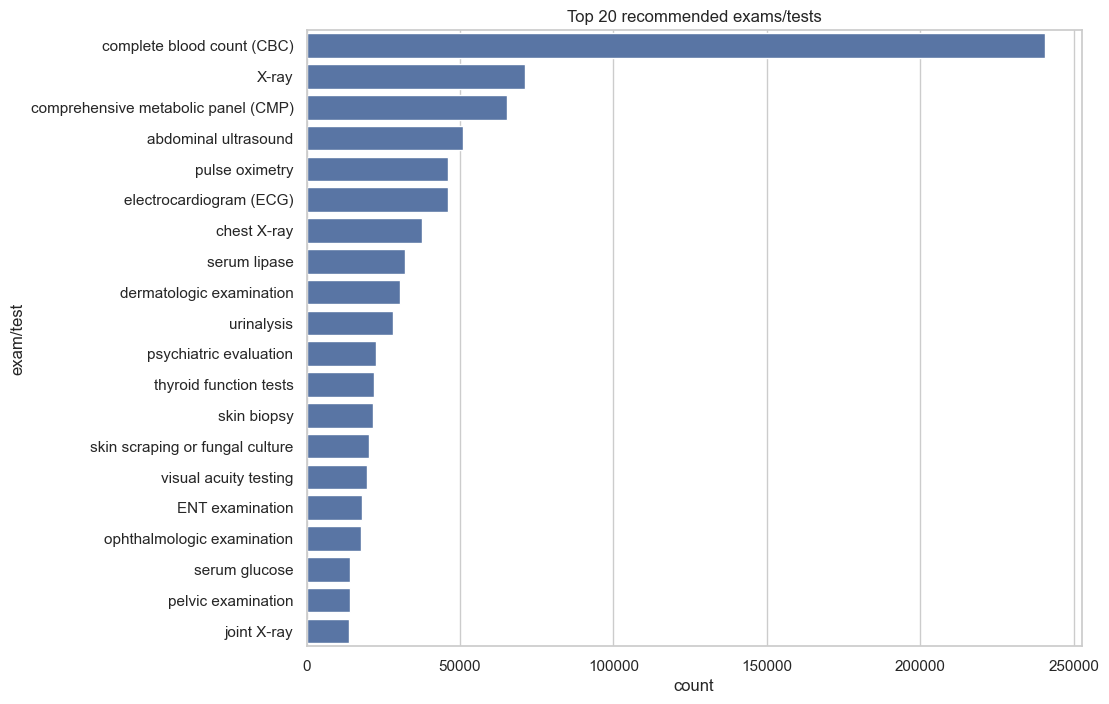

In [8]:
# Top recommended exams/tests (aggregate)
if 'df' in globals():
    e = Counter()
    df['recommended_exams_tests_parsed'].apply(e.update)
    top_exams = e.most_common(30)
    top_exams_df = pd.DataFrame(top_exams, columns=['exam','count'])
    print('Top recommended exams/tests (top 20):')
    display(top_exams_df.head(20))
    plt.figure(figsize=(10,8))
    sns.barplot(x='count', y='exam', data=top_exams_df.head(20))
    plt.title('Top 20 recommended exams/tests')
    plt.xlabel('count')
    plt.ylabel('exam/test')
    plt.show()

In [9]:
# Check whether the original 'output' label appears among candidate_diseases
if 'df' in globals():
    def output_in_candidates(row):
        out = row.get('output')
        cand = row.get('candidate_diseases_parsed', [])
        try:
            return bool(out) and out in cand
        except Exception:
            return False

    df['output_in_candidates'] = df.apply(output_in_candidates, axis=1)
    summary = df.groupby('support_status')['output_in_candidates'].agg(['sum','count','mean']).reset_index()
    summary['fraction'] = summary['mean']
    display(summary)

,support_status,sum,count,mean,fraction
0,inconclusive,0,192260,0.000000,0.000000
1,supported,52662,55866,0.942648,0.942648


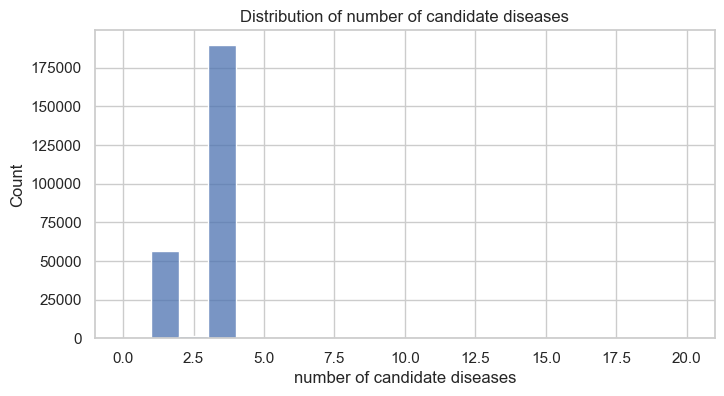

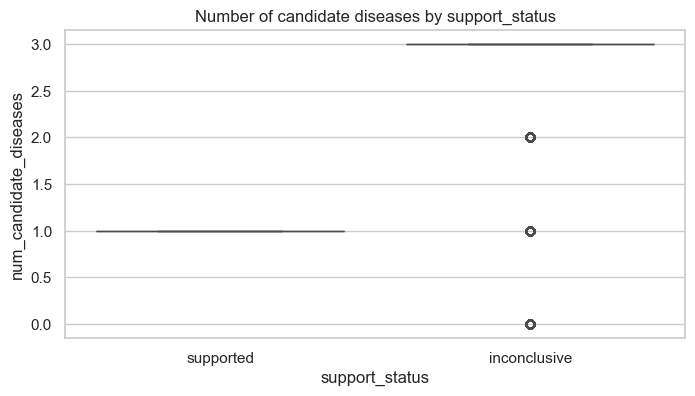

In [10]:
# Distribution of number of candidate diseases and relation to support_status
if 'df' in globals():
    plt.figure(figsize=(8,4))
    sns.histplot(df['num_candidate_diseases'], bins=range(0,21), kde=False)
    plt.title('Distribution of number of candidate diseases')
    plt.xlabel('number of candidate diseases')
    plt.show()

    plt.figure(figsize=(8,4))
    sns.boxplot(x='support_status', y='num_candidate_diseases', data=df)
    plt.title('Number of candidate diseases by support_status')
    plt.show()

,reasoning_len_chars,reasoning_len_words
count,248126.000000,248126.000000
mean,1576.257772,217.573297
std,122.367214,15.333668
min,756.000000,110.000000
25%,1530.000000,212.000000
50%,1604.000000,221.000000
75%,1656.000000,227.000000
max,2039.000000,282.000000


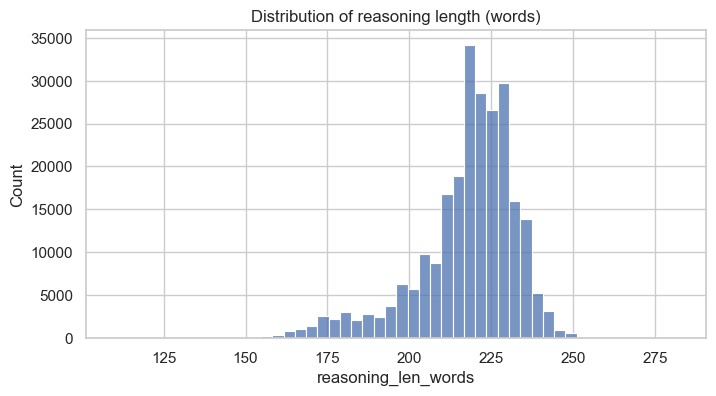

In [11]:
# Reasoning length statistics (if present)
if 'df' in globals() and 'reasoning' in df.columns:
    df['reasoning_text'] = df['reasoning'].fillna('')
    df['reasoning_len_chars'] = df['reasoning_text'].apply(len)
    df['reasoning_len_words'] = df['reasoning_text'].apply(lambda s: len(s.split()))
    display(df[['reasoning_len_chars','reasoning_len_words']].describe())
    plt.figure(figsize=(8,4))
    sns.histplot(df['reasoning_len_words'], bins=50)
    plt.title('Distribution of reasoning length (words)')
    plt.show()
else:
    print('No "reasoning" column present to analyze lengths.')

In [12]:
# Save summary CSVs for quick reference
if 'df' in globals():
    try:
        top_df.to_csv('top_candidate_diseases.csv', index=False)
        top_exams_df.to_csv('top_recommended_exams.csv', index=False)
    except Exception:
        # Fallback variable names if cells were re-executed in different order
        if 'top_df' in globals():
            top_df.to_csv('top_candidate_diseases.csv', index=False)
        if 'top_exams_df' in globals():
            top_exams_df.to_csv('top_recommended_exams.csv', index=False)
    df.groupby('support_status').size().reset_index(name='count').to_csv('support_status_counts.csv', index=False)
    print('Saved: top_candidate_diseases.csv, top_recommended_exams.csv, support_status_counts.csv')

Saved: top_candidate_diseases.csv, top_recommended_exams.csv, support_status_counts.csv


## Next steps / notes
- Consider publishing a small Kaggle notebook that includes selected plots and the `to_example` conversion used for fine‑tuning (prompt / target pairs).
- Add stricter validation: row‑aware checks that compare the extracted disease against `candidate_diseases` and `support_status`.
- Provide a separate script to convert the CSV into a training JSONL for the target fine‑tuning framework.
- If exam suggestions are noisy, consider manual curation or mapping exams to a normalized vocabulary.